## Jet Image Pre-training with Vision Transformer

This notebook sets up a self-supervised pre-training pipeline for jet images using an unlabelled HDF5 dataset.

1. **Data Inspection** – Open the HDF5 file and examine the structure/shape of the `jet` dataset (125×125×8 images with 8 channels).
2. **PyTorch Dataset** – Define `JetUnlabelledDataset`, which lazily loads jet images, converts them to `(C, H, W)` tensors, and applies zero-mean/unit-variance normalization.
3. **Train / Val Split & DataLoaders** – Split the dataset 95/5 into training and validation sets and wrap them in `DataLoader`s for batched iteration.

In [1]:
import h5py
import torch
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import random_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import random

import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

In [2]:
with h5py.File('data/Dataset_Specific_Unlabelled.h5', 'r') as f:
    print("Top-level keys:", list(f.keys()))

    jet = f['jet']
    print("Type of 'jet':", type(jet))

    if isinstance(jet, h5py.Dataset):
        print("Shape:", jet.shape)
        first = jet[0]
        print("First item shape:", first.shape)

Top-level keys: ['jet']
Type of 'jet': <class 'h5py._hl.dataset.Dataset'>
Shape: (60000, 125, 125, 8)
First item shape: (125, 125, 8)


In [3]:
class JetUnlabelledDataset(Dataset):
    def __init__(self, h5_path):
        self.h5_path = h5_path
        self.file = None  # opened lazily

        # read shape without keeping file open
        with h5py.File(h5_path, "r") as f:
            self.length = f["jet"].shape[0]

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # open file inside worker if needed
        if self.file is None:
            self.file = h5py.File(self.h5_path, "r")
        
        x = self.file["jet"][idx]  # (125,125,8)
        x = torch.tensor(x, dtype=torch.float32)

        # convert to (C,H,W)
        x = x.permute(2, 0, 1)

        x = (x - x.mean()) / (x.std() + 1e-6)

        return x

In [4]:
dataset = JetUnlabelledDataset("data/Dataset_Specific_Unlabelled.h5")

val_size = int(0.05 * len(dataset))
train_size = len(dataset) - val_size

train_ds, val_ds = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)

## Sanity Check: Visualizing Ulabelled and Labelled Data

Before training any model, I must verify what the input data looks like.

Sample shape: torch.Size([8, 125, 125])
Min value: -0.07398991286754608
Max value: 26.513633728027344
Mean value: -9.765624975344167e-10
Std value: 0.9999998807907104


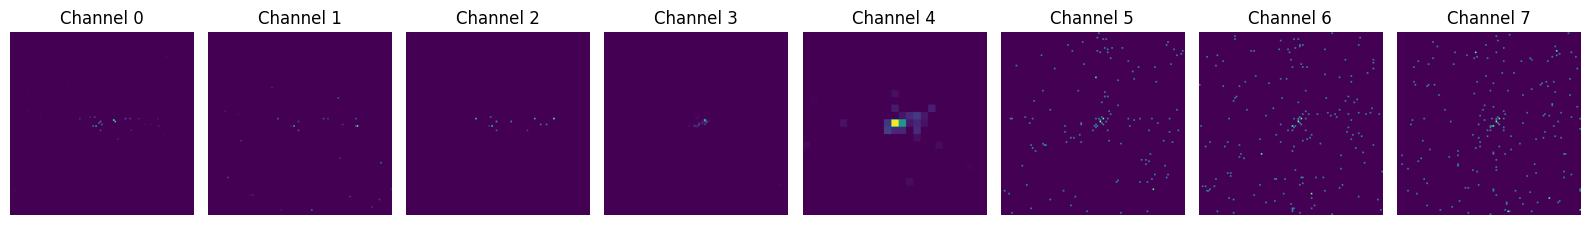

In [5]:
# get one random sample from training dataset
idx = random.randint(0, len(train_ds)-1)
sample = train_ds[idx]   # shape: (8,125,125)

print("Sample shape:", sample.shape)
print("Min value:", sample.min().item())
print("Max value:", sample.max().item())
print("Mean value:", sample.mean().item())
print("Std value:", sample.std().item())

# visualize first 4 channels
num_channels_to_plot = 8

fig, axes = plt.subplots(1, num_channels_to_plot, figsize=(16,4))

for i in range(num_channels_to_plot):
    axes[i].imshow(sample[i].cpu(), cmap="viridis")
    axes[i].set_title(f"Channel {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [6]:
path = "data/Dataset_Specific_labelled_full_only_for_2i.h5"

def explore(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"{name} -> DATASET shape={obj.shape} dtype={obj.dtype}")
    else:
        print(f"{name} -> GROUP")

with h5py.File(path, "r") as f:
    print("Top-level keys:", list(f.keys()))
    print("\nFull structure:\n")
    f.visititems(explore)

with h5py.File(path, "r") as f:
    jet = f["jet"][0]
    print("Jet shape:", jet.shape)

    for k in f.keys():
        if k != "jet":
            print(k, "sample value:", f[k][0])

Top-level keys: ['Y', 'jet', 'm', 'pT']

Full structure:

Y -> DATASET shape=(10000, 1) dtype=float32
jet -> DATASET shape=(10000, 125, 125, 8) dtype=float32
m -> DATASET shape=(10000, 1) dtype=float32
pT -> DATASET shape=(10000, 1) dtype=float32
Jet shape: (125, 125, 8)
Y sample value: [1.]
m sample value: [136.34013]
pT sample value: [551.3493]


---------[Y]---------
Shape: (10000,)
dtype: float32
Min: 0.0
Max: 1.0
Unique values (first 20): [0. 1.]
Number of unique values: 2
---------[m]---------
Shape: (10000,)
dtype: float32
Min: 31.948496
Max: 728.3518
Unique values (first 20): [31.948496 37.162827 37.652603 38.178566 40.40662  42.476177 43.35503
 43.417694 44.285244 45.752937 46.323708 46.597603 46.610394 46.872013
 46.905388 46.91361  46.92877  46.98776  46.99083  47.015266]
Number of unique values: 9993
---------[pT]---------
Shape: (10000,)
dtype: float32
Min: 400.01608
Max: 2039.6335
Unique values (first 20): [400.01608 400.04034 400.05087 400.07315 400.0838  400.0869  400.2837
 400.2934  400.31705 400.34348 400.4446  400.46985 400.47272 400.48547
 400.48703 400.49677 400.51898 400.5383  400.53998 400.5431 ]
Number of unique values: 9984


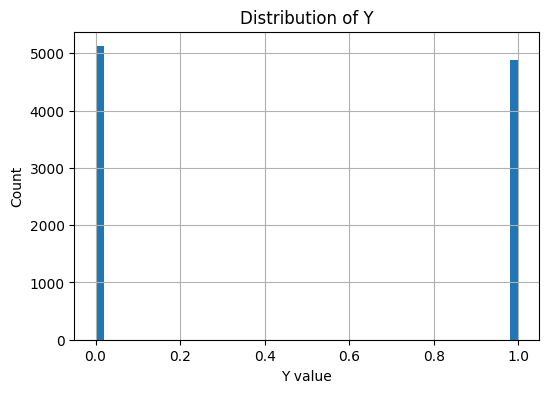

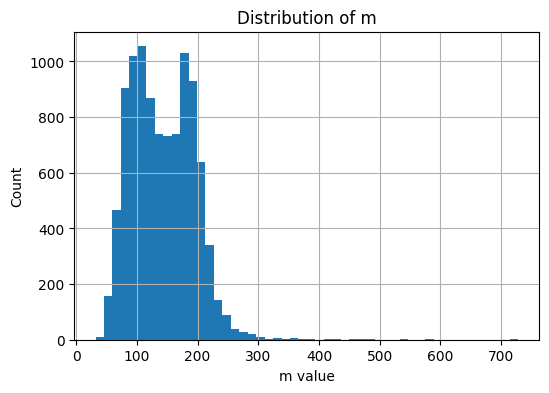

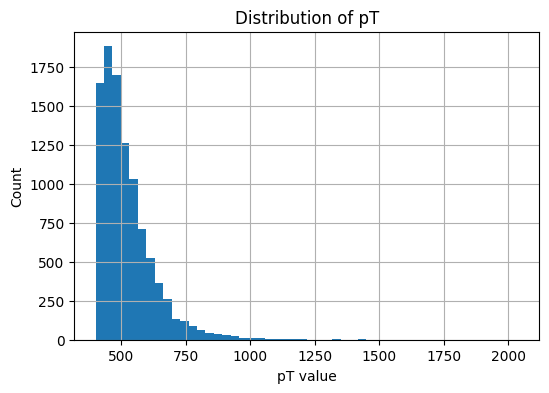

In [7]:
with h5py.File(path, "r") as f:
    Y = f["Y"][:].squeeze()
    m = f["m"][:].squeeze()
    pT = f["pT"][:].squeeze()

print("---------[Y]---------")
print("Shape:", Y.shape)
print("dtype:", Y.dtype)
print("Min:", Y.min())
print("Max:", Y.max())
print("Unique values (first 20):", np.unique(Y)[:20])
print("Number of unique values:", len(np.unique(Y)))

print("---------[m]---------")
print("Shape:", m.shape)
print("dtype:", m.dtype)
print("Min:", m.min())
print("Max:", m.max())
print("Unique values (first 20):", np.unique(m)[:20])
print("Number of unique values:", len(np.unique(m)))

print("---------[pT]---------")
print("Shape:", pT.shape)
print("dtype:", pT.dtype)
print("Min:", pT.min())
print("Max:", pT.max())
print("Unique values (first 20):", np.unique(pT)[:20])
print("Number of unique values:", len(np.unique(pT)))

# histogram
plt.figure(figsize=(6,4))
plt.hist(Y, bins=50)
plt.title("Distribution of Y")
plt.xlabel("Y value")
plt.ylabel("Count")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.hist(m, bins=50)
plt.title("Distribution of m")
plt.xlabel("m value")
plt.ylabel("Count")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.hist(pT, bins=50)
plt.title("Distribution of pT")
plt.xlabel("pT value")
plt.ylabel("Count")
plt.grid(True)
plt.show()

## Pretraining: Masked Autoencoder for Jet Representation Learning

I pretrain a Vision Transformer encoder on the unlabelled jet dataset using a masked reconstruction objective.

Each jet image (8 × 125 × 125) is split into 5×5 patches → 625 tokens.

During training:
- 75% of patches are randomly masked
- Encoder processes only visible patches
- A lightweight decoder reconstructs the original patches
- Loss = Mean Squared Error between Masked Patches

After pretraining, I will:
- Save encoder weights
- Fine-tune on labelled dataset
- Compare against training from scratch

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

class PatchEmbed(nn.Module):
    def __init__(self, in_ch=8, embed_dim=192, patch=5):
        super().__init__()
        self.patch = patch
        self.proj = nn.Conv2d(in_ch, embed_dim,
                              kernel_size=patch,
                              stride=patch)

    def forward(self, x):
        x = self.proj(x)                        # (B, D, 25, 25)
        B, D, H, W = x.shape
        x = x.permute(0, 2, 3, 1).contiguous()  # (B, 25, 25, D)
        x = x.reshape(B, H * W, D)              # (B, 625, D)
        return x

class Attention(nn.Module):
    def __init__(self, dim, heads=6, eps=1e-6):
        super().__init__()
        if dim % heads != 0:
            raise ValueError("dim must be divisible by heads")

        self.norm = nn.LayerNorm(dim)
        self.heads = heads
        self.head_dim = dim // heads
        self.eps = eps

        self.to_qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        y = self.norm(x)
        B, N, C = y.shape

        qkv = self.to_qkv(y).reshape(B, N, 3, self.heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, H, N, Dh)
        q, k, v = qkv[0], qkv[1], qkv[2]

        q = F.elu(q) + 1.0
        k = F.elu(k) + 1.0

        kv = torch.einsum("b h n d, b h n e -> b h d e", k, v)
        k_sum = k.sum(dim=2)  # (B, H, Dh)

        z = 1.0 / (torch.einsum("b h n d, b h d -> b h n", q, k_sum) + self.eps)
        out = torch.einsum("b h n d, b h d e, b h n -> b h n e", q, kv, z)

        out = out.transpose(1, 2).contiguous().reshape(B, N, C)
        out = self.proj(out)
        return out

class Block(nn.Module):
    def __init__(self, dim, heads=6):
        super().__init__()
        self.attn = Attention(dim, heads=heads)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim*4),
            nn.GELU(),
            nn.Linear(dim*4, dim)
        )
        self.n2 = nn.LayerNorm(dim)

    def forward(self,x):
        x = x + self.attn(x)
        x = x + self.ff(self.n2(x))
        return x

class Encoder(nn.Module):
    def __init__(self, dim=192, depth=4, heads=6, patch=5, in_ch=8):
        super().__init__()
        self.patch = PatchEmbed(in_ch=in_ch, embed_dim=dim, patch=patch)
        grid = 125 // patch
        num_tokens = grid * grid
        self.pos = nn.Parameter(torch.randn(1, num_tokens, dim))
        self.blocks = nn.Sequential(*[Block(dim, heads=heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        x = self.patch(x)
        x = x + self.pos
        x = self.blocks(x)
        x = self.norm(x)
        return x

class MAE(nn.Module):
    def __init__(self, dim=192, depth=4, heads=6, patch=5, in_ch=8, mask_ratio=0.40):
        super().__init__()
        self.encoder = Encoder(dim=dim, depth=depth, heads=heads, patch=patch, in_ch=in_ch)
        # Simple projection head to get back to pixels
        self.decoder = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Linear(dim, in_ch * patch * patch) # channels * patch * patch
        )
        self.mask_ratio = mask_ratio
        self.patch_size = patch
        self.in_ch = in_ch
        
        # 1. Learnable [MASK] token
        self.mask_token = nn.Parameter(torch.zeros(1, 1, dim))
        torch.nn.init.normal_(self.mask_token, std=.02)

    def patchify(self, imgs):
        B, C, H, W = imgs.shape
        p = self.patch_size
        h, w = H // p, W // p
        x = imgs.reshape(B, C, h, p, w, p)
        x = x.permute(0, 2, 4, 1, 3, 5).contiguous()
        x = x.reshape(B, h * w, C * p * p)
        return x

    def forward(self, x):
        B = x.size(0)
        
        # 1. Create Ground Truth Patches
        target = self.patchify(x)
        
        # 2. Create Embeddings
        tokens = self.encoder.patch(x) # (B, N, D)
        B, N, D = tokens.shape

        # 3. Create Mask
        mask_count = int(N * self.mask_ratio)
        noise = torch.rand(B, N, device=x.device)
        ids = torch.argsort(noise, dim=1)
        
        # indices to mask (the first 'mask_count' ones)
        mask_idx = ids[:, :mask_count]
        
        # 4. Apply Masking
        masked_tokens = tokens.clone()
        
        # Advanced indexing to replace masked positions with the learnable parameter
        batch_range = torch.arange(B, device=x.device)[:, None]
        masked_tokens[batch_range, mask_idx] = self.mask_token

        # 5. Add Positional Embeddings & Encode
        masked_tokens = masked_tokens + self.encoder.pos
        encoded = self.encoder.blocks(masked_tokens)
        encoded = self.encoder.norm(encoded)

        # 6. Predict Everything
        reconstruction = self.decoder(encoded) # (B, N, C*p*p)

        # 7. Calculate Loss ONLY on Masked Patches
        pred_masked = reconstruction[batch_range, mask_idx]
        target_masked = target[batch_range, mask_idx]
        loss = ((pred_masked - target_masked)**2).mean()
        
        return loss

Using device: cuda


Epoch 1/20:   0%|          | 0/1782 [00:00<?, ?it/s]

Epoch 1/20: 100%|██████████| 1782/1782 [02:55<00:00, 10.13it/s, loss=0.778]


Epoch 1: Train_loss=0.8246 | Val_loss=0.8101


Epoch 2/20: 100%|██████████| 1782/1782 [02:52<00:00, 10.34it/s, loss=0.808]


...

Epoch 18: Train_loss=0.7885 | Val_loss=0.7932


Epoch 19/20: 100%|██████████| 1782/1782 [08:02<00:00,  3.70it/s, loss=0.796]


Epoch 19: Train_loss=0.7880 | Val_loss=0.7914


Epoch 20/20: 100%|██████████| 1782/1782 [08:43<00:00,  3.40it/s, loss=0.722]


Epoch 20: Train_loss=0.7873 | Val_loss=0.7902


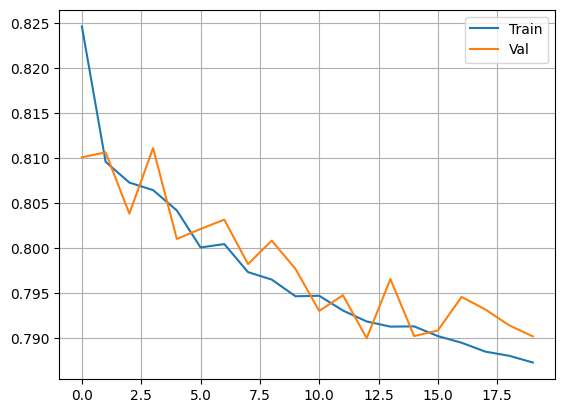

In [45]:
print("Using device:", device)

model = MAE().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 20
train_history = []
val_history = []

for epoch in range(epochs):
    model.train()
    train_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for batch in loop:
        if isinstance(batch, (list, tuple)):
            batch = batch[0]
        batch = batch.to(device)

        loss = model(batch)

        opt.zero_grad()
        loss.backward()
        opt.step()

        train_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    train_loss /= len(train_loader)
    train_history.append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            if isinstance(batch, (list, tuple)):
                batch = batch[0]
            batch = batch.to(device)
            loss = model(batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_history.append(val_loss)

    print(f"Epoch {epoch+1}: Train_loss={train_loss:.4f} | Val_loss={val_loss:.4f}")

torch.save(model.encoder.state_dict(), "pretrained_encoder_60_percent_masking.pt")

plt.plot(train_history, label="Train")
plt.plot(val_history, label="Val")
plt.legend()
plt.grid(True)
plt.show()

## Fine-tuning for Binary Classification

The labelled dataset contains:

- jet: (10000, 125, 125, 8)
- Y:   binary labels {0,1}

We therefore treat this as a binary classification task.

Procedure:
1. 80% train / 20% test split
2. Fine-tune pretrained encoder with low learning rate
3. Train identical model from scratch
4. Compare test accuracy and training dynamics

Loss: Binary Cross Entropy with Logits
Metric: Accuracy

In [11]:
import torch
import h5py
from torch.utils.data import Dataset

class JetDataset(Dataset):
    def __init__(self, h5_path, task="cls"):
        self.h5_path = h5_path
        self.file = None
        self.task = task

        with h5py.File(h5_path, "r") as f:
            self.length = f["jet"].shape[0]
            self.available_keys = set(f.keys())

            # --- THE FIX: Pre-calculate target stats for regression ---
            if self.task == "mass":
                if "m" not in self.available_keys:
                    raise KeyError("Dataset missing key 'm'")
                # Load the 1D array into RAM to get stats
                targets = f["m"][:] 
                self.y_mean = targets.mean()
                self.y_std = targets.std() + 1e-6
                
            elif self.task == "pt":
                if "pT" not in self.available_keys:
                    raise KeyError("Dataset missing key 'pT'")
                targets = f["pT"][:]
                self.y_mean = targets.mean()
                self.y_std = targets.std() + 1e-6

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        if self.file is None:
            self.file = h5py.File(self.h5_path, "r")

        # 1. Normalize Input (X)
        x = self.file["jet"][idx]
        x = torch.tensor(x, dtype=torch.float32).permute(2, 0, 1)
        x = (x - x.mean()) / (x.std() + 1e-6)

        # 2. Extract and Normalize Target (Y)
        if self.task == "cls":
            y = self.file["Y"][idx]
            # No normalization for binary classification labels
            
        elif self.task == "mass":
            raw_y = self.file["m"][idx]
            y = (raw_y - self.y_mean) / self.y_std # Normalize!
            
        elif self.task == "pt":
            raw_y = self.file["pT"][idx]
            y = (raw_y - self.y_mean) / self.y_std # Normalize!
            
        else:
            raise ValueError(f"Unknown task: {self.task}")

        y = torch.tensor(y, dtype=torch.float32).squeeze()
        return x, y

In [12]:
def make_loaders(task, batch_size=32, val_frac_from_train=0.1):
    dataset = JetDataset("data/Dataset_Specific_labelled_full_only_for_2i.h5", task)

    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size

    train_full, test_ds = random_split(
        dataset,
        [train_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )

    val_size = int(val_frac_from_train * len(train_full))
    val_size = max(1, val_size)
    train_size_final = len(train_full) - val_size

    train_ds, val_ds = random_split(
        train_full,
        [train_size_final, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [13]:
class FinetuneModel(nn.Module):
    def __init__(self, encoder, out_dim=1):
        super().__init__()
        self.encoder = encoder
        if isinstance(self.encoder.norm.normalized_shape, (tuple, list)):
            feat_dim = int(self.encoder.norm.normalized_shape[0])
        else:
            feat_dim = int(self.encoder.norm.normalized_shape)
        self.head = nn.Linear(feat_dim, out_dim)

    def forward(self, x):
        z = self.encoder(x).mean(dim=1)
        return self.head(z)

In [14]:
import numpy as np
import copy
import os
import json
from pathlib import Path

torch.manual_seed(67)
np.random.seed(67)

os.makedirs("weights", exist_ok=True)

# Set this folder name to choose which pretrained run to load
CHECKPOINT_FOLDER = "linear_base_lowmask_mask40_bs32_p5_dim192_d4_h6_lr0.0001_wd0.0001_ep100_seed67"

def _load_checkpoint_artifacts(folder_name, base_dir="checkpoints"):
    run_dir = Path(base_dir) / folder_name
    hp_path = run_dir / "hyperparams.json"
    ckpt_path = run_dir / "pretrained_encoder_best.pt"

    if not run_dir.exists():
        raise FileNotFoundError(f"Checkpoint folder not found: {run_dir}")
    if not hp_path.exists():
        raise FileNotFoundError(f"Missing hyperparams.json in: {run_dir}")
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Missing pretrained_encoder_best.pt in: {run_dir}")

    with hp_path.open("r", encoding="utf-8") as f:
        hyperparams = json.load(f)

    return run_dir, ckpt_path, hyperparams

def _encoder_kwargs_from_hparams(hp):
    return {
        "dim": int(hp.get("dim", 192)),
        "depth": int(hp.get("depth", 4)),
        "heads": int(hp.get("heads", 6)),
        "patch": int(hp.get("patch", 5)),
        "in_ch": int(hp.get("in_ch", 8)),
    }

def build_model(pretrained=True, checkpoint_folder=CHECKPOINT_FOLDER):
    if pretrained:
        run_dir, ckpt_path, hp = _load_checkpoint_artifacts(checkpoint_folder, base_dir="checkpoints")
        encoder_kwargs = _encoder_kwargs_from_hparams(hp)
        encoder = Encoder(**encoder_kwargs).to(device)

        print("Loading pretrained encoder from:", ckpt_path)
        print("Loaded hyperparams from:", run_dir / "hyperparams.json")
        print({k: hp.get(k) for k in ["dim", "depth", "heads", "patch", "mask_ratio", "batch_size", "lr", "weight_decay", "epochs", "seed"]})

        state = torch.load(ckpt_path, map_location=device, weights_only=True)
        encoder.load_state_dict(state)
    else:
        # Keep scratch architecture aligned to selected checkpoint run for fair comparison
        run_dir, _, hp = _load_checkpoint_artifacts(checkpoint_folder, base_dir="checkpoints")
        encoder_kwargs = _encoder_kwargs_from_hparams(hp)
        print("Scratch encoder architecture from:", run_dir / "hyperparams.json")
        print({k: hp.get(k) for k in ["dim", "depth", "heads", "patch"]})
        encoder = Encoder(**encoder_kwargs).to(device)

    return FinetuneModel(encoder).to(device)

In [18]:
def evaluate_regression(model, loader):
    model.eval()
    total_loss = 0.0
    criterion = nn.MSELoss()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).float().view(-1)
            pred = model(x).squeeze(-1)
            loss = criterion(pred, y)
            total_loss += loss.item()
    return total_loss / max(1, len(loader))

def evaluate_classification(model, loader):
    model.eval()
    criterion = nn.BCEWithLogitsLoss()
    total_loss = 0.0
    logits_all, labels_all = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).float().view(-1)
            logits = model(x).squeeze(-1)
            loss = criterion(logits, y)

            total_loss += loss.item()
            logits_all.append(logits.detach().cpu())
            labels_all.append(y.detach().cpu())

    logits_all = torch.cat(logits_all).numpy()
    labels_all = torch.cat(labels_all).numpy()
    probs = 1.0 / (1.0 + np.exp(-logits_all))
    preds = (probs >= 0.5).astype(np.int32)
    acc = (preds == labels_all.astype(np.int32)).mean()

    return {
        "loss": total_loss / max(1, len(loader)),
        "labels": labels_all.astype(np.int32),
        "probs": probs,
        "preds": preds,
        "acc": acc,
    }

def train_and_eval(task, pretrained=True, lr=1e-4, head_lr=1e-3 ,epochs=12, patience=3):
    train_loader, val_loader, test_loader = make_loaders(task)
    model = build_model(pretrained=pretrained)

    is_cls = task == "cls"
    criterion = nn.BCEWithLogitsLoss() if is_cls else nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    # Split Learning Rates
    if pretrained:
        # Protect the encoder with a tiny LR, train the head aggressively
        optimizer = torch.optim.Adam([
            {'params': model.encoder.parameters(), 'lr': lr},
            {'params': model.head.parameters(), 'lr': head_lr}
        ], weight_decay=1e-4)
    else:
        # If training from scratch, apply the same LR everywhere
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    history = {"train": [], "val": [], "train_acc": [], "val_acc": []}
    best_state = None
    best_val = float("inf")
    bad_epochs = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for x, y in tqdm(train_loader, leave=False, desc=f"{task} ep {epoch+1}/{epochs}"):
            x = x.to(device)
            y = y.to(device).float().view(-1)

            out = model(x).squeeze(-1)
            loss = criterion(out, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            if is_cls:
                probs = torch.sigmoid(out)
                preds = (probs >= 0.5).float()
                train_correct += (preds == y).sum().item()
                train_total += y.numel()

        train_loss /= max(1, len(train_loader))

        if is_cls:
            val_metrics = evaluate_classification(model, val_loader)
            val_loss = val_metrics["loss"]
            train_acc = train_correct / max(1, train_total)
            val_acc = val_metrics["acc"]
        else:
            val_loss = evaluate_regression(model, val_loader)
            train_acc = np.nan
            val_acc = np.nan

        history["train"].append(train_loss)
        history["val"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        improved = val_loss < best_val
        if improved:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if is_cls:
            print(f"{task} | {'pre' if pretrained else 'scratch'} | epoch {epoch+1} | train={train_loss:.4f} | val={val_loss:.4f} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}")
        else:
            print(f"{task} | {'pre' if pretrained else 'scratch'} | epoch {epoch+1} | train={train_loss:.4f} | val={val_loss:.4f}")

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    if is_cls:
        test_metrics = evaluate_classification(model, test_loader)
    else:
        test_metrics = {"loss": evaluate_regression(model, test_loader)}

    tag = "pretrained" if pretrained else "scratch"
    torch.save(model.state_dict(), f"weights/{task}_{tag}_finetune.pt")

    return history, test_metrics

## Experiment: Pretrained vs Scratch (Classification, Mass, pT)

This experiment follows the requested protocol:

- 80% labelled data for model development, 20% held-out test
- Inside the 80%, we use a train/validation split for early stopping
- We train and compare **pretrained** vs **scratch** models for:
  - Classification (`Y`)
  - Mass regression (`m`)
  - pT regression (`pT`)

For classification, we additionally report:

- Confusion matrix (TN, FP, FN, TP)
- ROC-AUC score
- ROC curve

Classification: Pretrained
Loading pretrained encoder from: checkpoints/linear_base_lowmask_mask40_bs32_p5_dim192_d4_h6_lr0.0001_wd0.0001_ep100_seed67/pretrained_encoder_best.pt
Loaded hyperparams from: checkpoints/linear_base_lowmask_mask40_bs32_p5_dim192_d4_h6_lr0.0001_wd0.0001_ep100_seed67/hyperparams.json
{'dim': 192, 'depth': 4, 'heads': 6, 'patch': 5, 'mask_ratio': 0.4, 'batch_size': 32, 'lr': 0.0001, 'weight_decay': 0.0001, 'epochs': 100, 'seed': 67}


cls | pre | epoch 1 | train=0.4115 | val=0.3398 | train_acc=0.8269 | val_acc=0.8550


cls | pre | epoch 2 | train=0.3468 | val=0.2825 | train_acc=0.8549 | val_acc=0.8862


cls | pre | epoch 3 | train=0.3170 | val=0.2887 | train_acc=0.8715 | val_acc=0.8888


cls | pre | epoch 4 | train=0.2984 | val=0.2827 | train_acc=0.8778 | val_acc=0.8862


...

cls | scratch | epoch 6 | train=0.4646 | val=0.4401 | train_acc=0.7889 | val_acc=0.8200


cls | scratch | epoch 7 | train=0.4626 | val=0.4217 | train_acc=0.7865 | val_acc=0.8175


cls | scratch | epoch 8 | train=0.4641 | val=0.4845 | train_acc=0.7868 | val_acc=0.7662


cls | scratch | epoch 9 | train=0.4558 | val=0.4075 | train_acc=0.7918 | val_acc=0.8300


cls | scratch | epoch 10 | train=0.4330 | val=0.4198 | train_acc=0.8065 | val_acc=0.8275


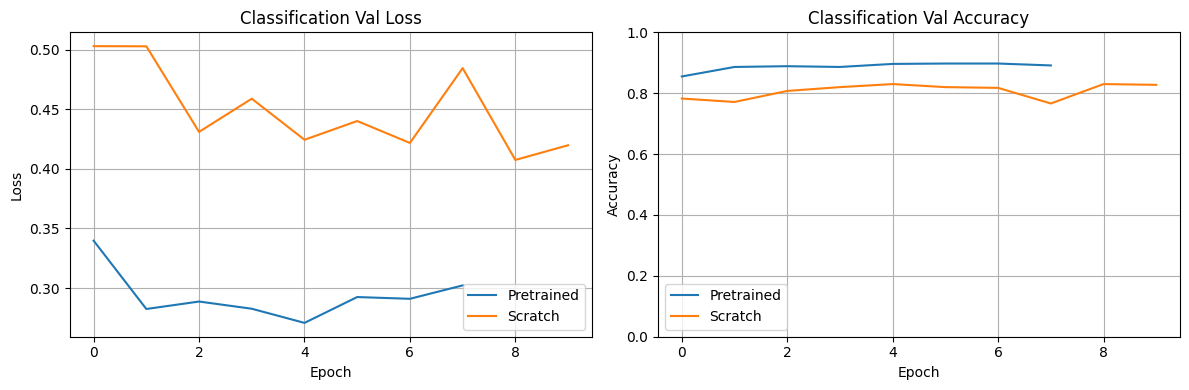


Pretrained Classification Test Metrics
Loss: 0.3118
Accuracy: 0.8740
TN=835, FP=180, FN=72, TP=913
ROC-AUC: 0.9385

Scratch Classification Test Metrics
Loss: 0.4204
Accuracy: 0.8165
TN=808, FP=207, FN=160, TP=825
ROC-AUC: 0.8821


/tmp/ipykernel_20411/3177728669.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


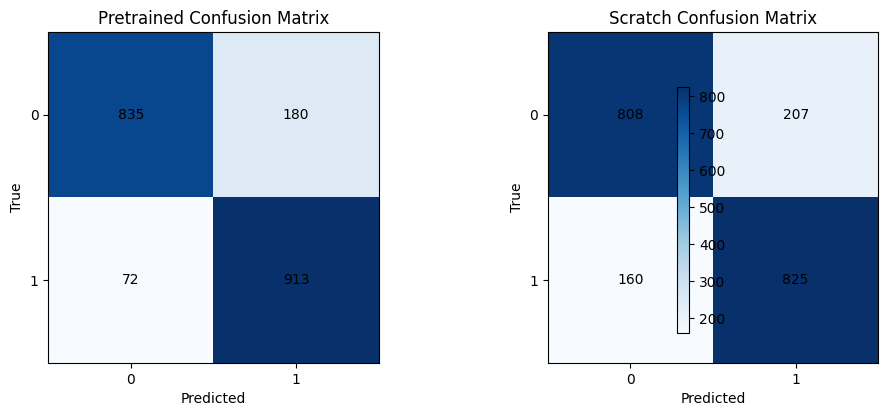

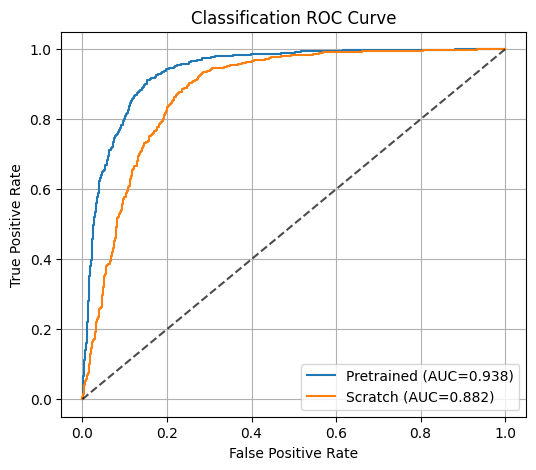

In [ ]:
print("Classification: Pretrained")
cls_pre_hist, cls_pre_test = train_and_eval("cls", pretrained=True, lr=1e-4, epochs=10, patience=3)

print("Classification: Scratch")
cls_scratch_hist, cls_scratch_test = train_and_eval("cls", pretrained=False, lr=1e-3, epochs=10, patience=3)

# Validation loss + accuracy comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(cls_pre_hist["val"], label="Pretrained")
axes[0].plot(cls_scratch_hist["val"], label="Scratch")
axes[0].set_title("Classification Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(cls_pre_hist["val_acc"], label="Pretrained")
axes[1].plot(cls_scratch_hist["val_acc"], label="Scratch")
axes[1].set_title("Classification Val Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

# Compute metrics + confusion matrix values
cls_results = {}
for name, out in [("Pretrained", cls_pre_test), ("Scratch", cls_scratch_test)]:
    tn, fp, fn, tp = confusion_matrix(out["labels"], out["preds"]).ravel()
    auc = roc_auc_score(out["labels"], out["probs"] )
    acc = (out["preds"] == out["labels"]).mean()
    cls_results[name] = {
        "cm": np.array([[tn, fp], [fn, tp]]),
        "auc": auc,
        "acc": acc,
        "loss": out["loss"],
        "labels": out["labels"],
        "probs": out["probs"]
    }

    print(f"\n{name} Classification Test Metrics")
    print(f"Loss: {out['loss']:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(f"ROC-AUC: {auc:.4f}")

# Confusion matrix plots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, ["Pretrained", "Scratch"]):
    cm = cls_results[name]["cm"]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.tight_layout()
plt.show()

# ROC curve
fpr_pre, tpr_pre, _ = roc_curve(cls_results["Pretrained"]["labels"], cls_results["Pretrained"]["probs"] )
fpr_scr, tpr_scr, _ = roc_curve(cls_results["Scratch"]["labels"], cls_results["Scratch"]["probs"] )

plt.figure(figsize=(6, 5))
plt.plot(fpr_pre, tpr_pre, label=f"Pretrained (AUC={cls_results['Pretrained']['auc']:.3f})")
plt.plot(fpr_scr, tpr_scr, label=f"Scratch (AUC={cls_results['Scratch']['auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Classification ROC Curve")
plt.grid(True)
plt.legend()
plt.show()

### Task 2: Mass Regression

Run pretrained vs scratch for `m` and compare validation/test MSE.

Mass: Pretrained
Loading pretrained encoder from: checkpoints/linear_base_lowmask_mask40_bs32_p5_dim192_d4_h6_lr0.0001_wd0.0001_ep100_seed67/pretrained_encoder_best.pt
Loaded hyperparams from: checkpoints/linear_base_lowmask_mask40_bs32_p5_dim192_d4_h6_lr0.0001_wd0.0001_ep100_seed67/hyperparams.json
{'dim': 192, 'depth': 4, 'heads': 6, 'patch': 5, 'mask_ratio': 0.4, 'batch_size': 32, 'lr': 0.0001, 'weight_decay': 0.0001, 'epochs': 100, 'seed': 67}


mass ep 1/25:   0%|          | 1/225 [00:00<00:40,  5.60it/s]

mass | pre | epoch 1 | train=0.5378 | val=0.3268


mass | pre | epoch 2 | train=0.4237 | val=0.3127


mass | pre | epoch 3 | train=0.4010 | val=0.3011


...

mass | scratch | epoch 21 | train=0.3022 | val=0.3851


mass | scratch | epoch 22 | train=0.2827 | val=0.3059


mass | scratch | epoch 23 | train=0.2798 | val=0.3714


mass | scratch | epoch 24 | train=0.2660 | val=0.3374


mass | scratch | epoch 25 | train=0.2635 | val=0.2882


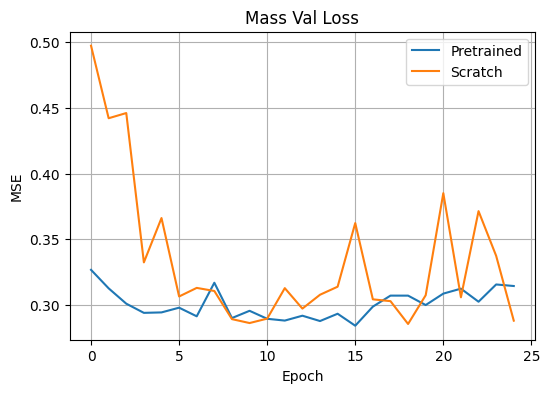

Mass Test MSE
Pretrained: 0.4419
Scratch:    0.4632


In [19]:
# --------- Task 2: Mass Regression ---------
print("Mass: Pretrained")
mass_pre_hist, mass_pre_test = train_and_eval(
    "mass", 
    pretrained=True, 
    lr=1e-5,          # Low learning rate to protect pre-trained features
    head_lr=1e-3,     # High learning rate to quickly train the new classification/regression head
    epochs=25, 
    patience=100
)

print("Mass: Scratch")
# For the scratch model, we just use a standard fast learning rate (1e-3) for the whole network
mass_scratch_hist, mass_scratch_test = train_and_eval(
    "mass", 
    pretrained=False, 
    lr=1e-3,          # Standard learning rate for everything
    head_lr=1e-3, 
    epochs=25, 
    patience=100
)

plt.figure(figsize=(6, 4))
plt.plot(mass_pre_hist["val"], label="Pretrained")
plt.plot(mass_scratch_hist["val"], label="Scratch")
plt.title("Mass Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(True)
plt.legend()
plt.show()

print("Mass Test MSE")
print(f"Pretrained: {mass_pre_test['loss']:.4f}")
print(f"Scratch:    {mass_scratch_test['loss']:.4f}")

### Task 3: pT Regression

Run pretrained vs scratch for `pT` and compare validation/test MSE.

In [ ]:
print("pT: Pretrained")
pt_pre_hist, pt_pre_test = train_and_eval("pt", pretrained=True, lr=1e-4, epochs=50, patience=30)

print("pT: Scratch")
pt_scratch_hist, pt_scratch_test = train_and_eval("pt", pretrained=False, lr=1e-4, epochs=50, patience=30)

plt.figure(figsize=(6, 4))
plt.plot(pt_pre_hist["val"], label="Pretrained")
plt.plot(pt_scratch_hist["val"], label="Scratch")
plt.title("pT Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(True)
plt.legend()
plt.show()

print("pT Test MSE")
print(f"Pretrained: {pt_pre_test['loss']:.4f}")
print(f"Scratch:    {pt_scratch_test['loss']:.4f}")

### Ideas to Improve Classification Accuracy

1. **Tune threshold, not only 0.5**
   - Pick decision threshold on validation set (maximize F1, balanced accuracy, or physics-driven operating point).

2. **Class imbalance handling**
   - If labels are imbalanced, use `BCEWithLogitsLoss(pos_weight=...)` and/or weighted sampling in the train loader.

3. **Stronger augmentation for jet images**
   - Mild geometric/intensity augmentations that preserve physics can improve generalization.

4. **Learning-rate schedule**
   - Keep low LR for pretrained encoder, but use cosine decay + warmup and potentially a slightly higher LR for classification head.

5. **Freeze-then-unfreeze strategy**
   - First train only the head for a few epochs, then unfreeze the full encoder.

6. **Longer training with early stopping**
   - Increase max epochs and rely on validation-based early stopping to avoid overfitting.

7. **Cross-validation on the 80% development split**
   - 3–5 folds can provide a more robust estimate and better hyperparameter selection before final test evaluation.